<a href="https://colab.research.google.com/github/karolinalipniak/customer-churn-analysis/blob/main/telco_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# 2. LOAD DATASET
# ================================

df = pd.read_csv("telco_churn.csv")

# Preview first rows
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
# ================================
# 3. DATA OVERVIEW
# ================================

# Basic info about dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


##Data Overview

The dataset contains 100,000 customer records and 9 features.
There are no missing values, which allows for a straightforward analysis process.

The dataset includes both numerical variables (e.g., Age, Tenure, MonthlyCharges) and categorical variables (e.g., Contract, PaymentMethod, Churn).

The target variable is "Churn", indicating whether a customer has left the service.

In [5]:
# Statistical summary of numerical columns
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


##Statistical Summary

The dataset shows realistic distributions for most numerical variables such as Age, Tenure, and MonthlyCharges.

However, the TotalCharges column contains negative values, which are not valid in a real-world scenario and indicate potential data quality issues.

Additionally, the mean of TotalCharges is higher than the median, suggesting the presence of high-value outliers.

In [6]:
# ================================
# 4. CHECK MISSING VALUES
# ================================

# Check if there are missing values in the dataset
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


##Missing Values Check

All columns have no significant missing values — dataset is ready for analysis.

In [7]:
# ================================
# 5. DATA CLEANING
# ================================

# Remove invalid values (e.g. negative charges)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

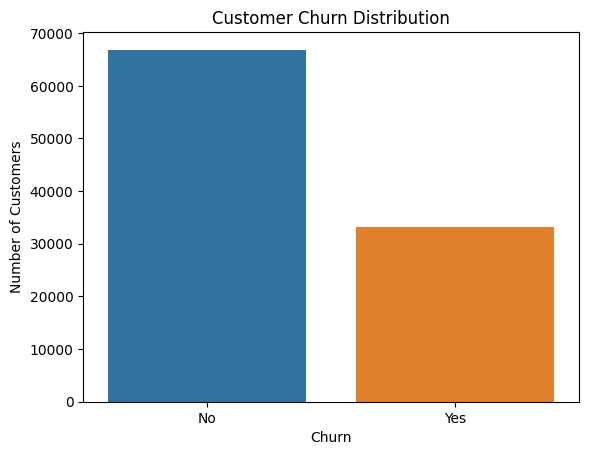

In [8]:
# ================================
# 6. VISUALISATIONS
# ================================


# ---- 6.1 Churn distribution ----
sns.countplot(x="Churn", hue="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Churn Distribution

Most customers **do not churn**, but a significant portion leaves, so churn analysis is important.

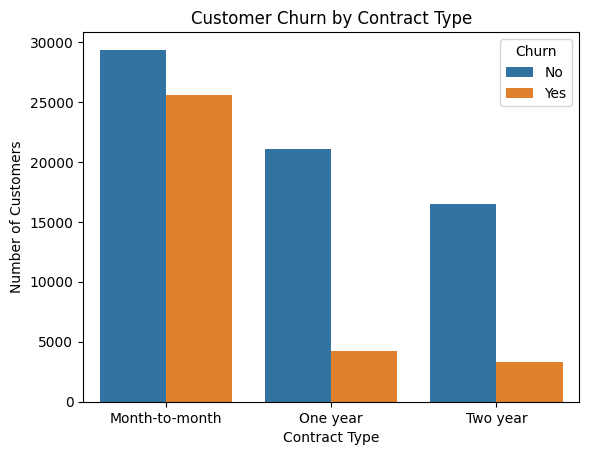

In [9]:
# ---- 6.2 Churn by Contract Type (sorted logically) ----
contract_order = ["Month-to-month", "One year", "Two year"]

sns.countplot(x="Contract", hue="Churn", data=df, order=contract_order)
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

## Churn by Contract Type

Customers on **month-to-month contracts** have the highest churn, while churn decreases for **one-year** and **two-year contracts**.  
Sorting contracts logically makes the trend by contract duration immediately clear.


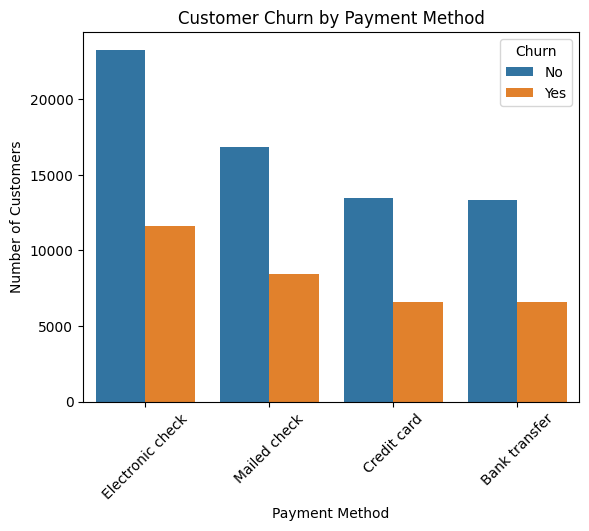

In [10]:
# ---- 6.3 Churn by Payment Method (sorted) ----
payment_order = df["PaymentMethod"].value_counts().index

sns.countplot(x="PaymentMethod", hue="Churn", data=df, order=payment_order)
plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## Churn by Payment Method

Payment methods like **Electronic check** show higher churn, while methods like **Credit card (automatic)** or **Bank transfer (automatic)** have lower churn.  
Sorting by total number of customers improves readability.

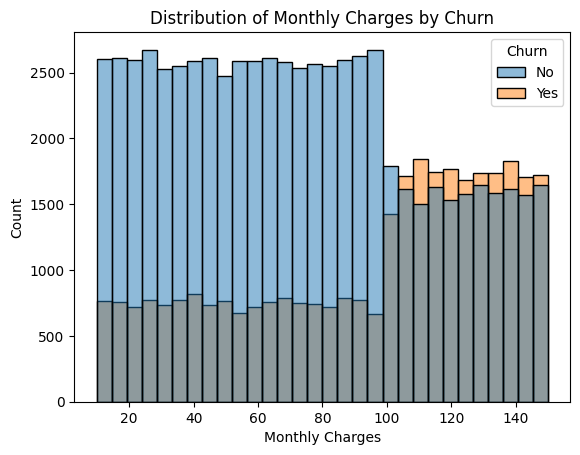

In [11]:
# ---- 6.4 Churn by Monthly Charges ----
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30)
plt.title("Distribution of Monthly Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()


## Monthly Charges vs Churn

Customers with **higher monthly charges** tend to churn more frequently.  
Histogram shows how churn is distributed across different charge levels.

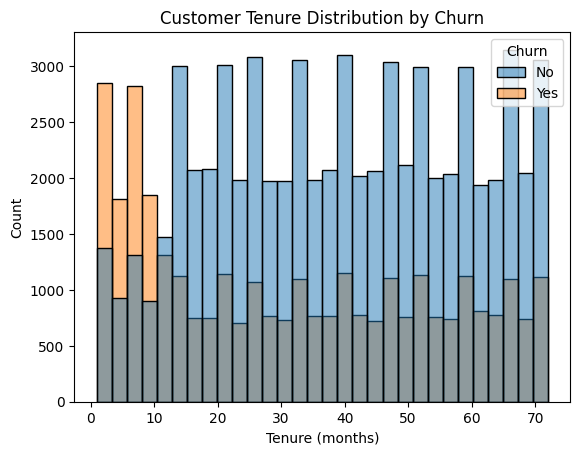

In [12]:
# ---- 6.5 Churn by Tenure ----
sns.histplot(data=df, x="Tenure", hue="Churn", bins=30)
plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

## Tenure vs Churn

Customers with **shorter tenure** are more likely to churn, while long-term customers tend to stay.

## Key Findings

After analyzing the Telco Churn dataset, the following key insights were observed:

- Customers on month-to-month contracts churn the most.
- Short-tenure customers are more likely to leave.
- Certain payment methods, e.g., Electronic Check, show higher churn.
- Higher Monthly Charges correlate with higher churn probability.

In [18]:
# ================================
# 7. MACHINE LEARNING MODELS
# ================================

# ---- 7.1 Data preparation ----

# Copy dataset
df_ml = df.copy()

# 🔥 DROP ID FIRST
df_ml = df_ml.drop(columns=["CustomerID"], errors="ignore")

# Target
df_ml["Churn"] = df_ml["Churn"].map({"No": 0, "Yes": 1})

# Fix TotalCharges
df_ml["TotalCharges"] = pd.to_numeric(df_ml["TotalCharges"], errors="coerce")

# Remove missing
df_ml = df_ml.dropna()

# Encoding
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Split
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]

# CHECK
print("CustomerID in X:", any("CustomerID" in col for col in X.columns))

CustomerID in X: False


In [14]:
# ---- 7.2 Train-Test split ----

from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# ---- 7.3 Logistic regression ----

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7234

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.85      0.80     13371
           1       0.61      0.47      0.53      6629

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.67     20000
weighted avg       0.71      0.72      0.71     20000



In [16]:
# ---- 7.4 Random Forest ----

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.732

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81     13371
           1       0.62      0.51      0.56      6629

    accuracy                           0.73     20000
   macro avg       0.70      0.68      0.68     20000
weighted avg       0.72      0.73      0.72     20000



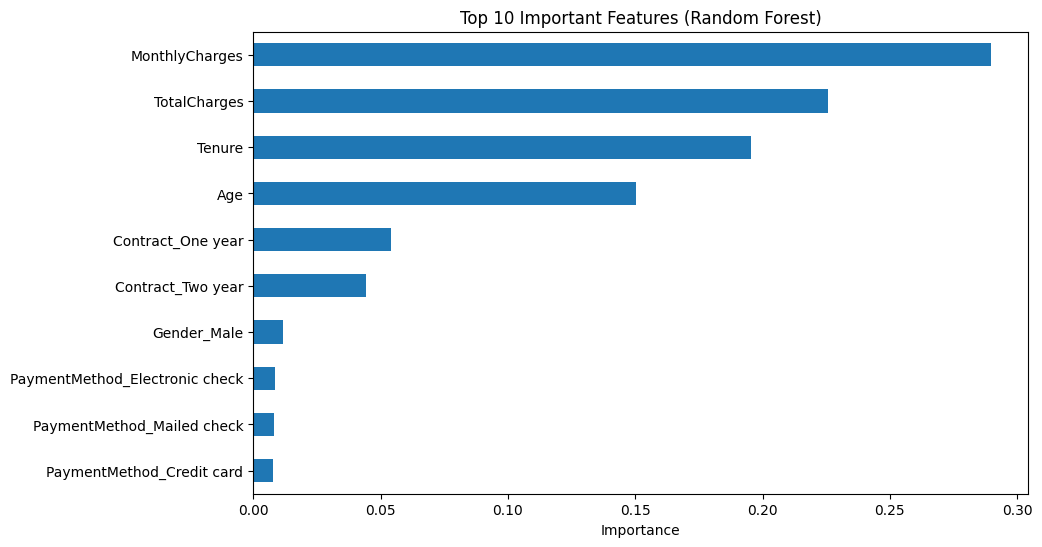

In [17]:
# ---- 7.5 Feature importance ----

import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

## Summary

Two models were implemented to predict customer churn:

- Logistic Regression provided a simple and interpretable baseline.
- Random Forest achieved better performance by capturing complex relationships in the data.

The results indicate that customer churn is influenced by multiple interacting factors rather than a single variable.

Key predictors identified by the model include **contract type, tenure, and monthly charges**, which align with findings from the exploratory data analysis.

During model preparation, non-informative features such as CustomerID were removed to prevent overfitting and ensure meaningful predictions.

This project demonstrates how combining EDA with machine learning can provide deeper insights into customer behavior and improve predictive analysis.